In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: ______________________
- PRN : ______________________
- Date: ______________________

# Deep Neural Network
## Assignment A05

## Tensor Flow
- Select number of layers
- Select node in each of the layers
- Choose activation function
- multi-class - Fashion MNIST dataset (all 60000 images)
- Implement one or more of following to achieve max accuracy.
    - L1/ L2 Regularization
    - Dropout
    - Batch Normalization
    - Early stopping
- Save model

In [43]:
###-----------------
### Import Libraries
###-----------------
import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay
from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix

In [3]:
###-----------------
### Global Variables
###-----------------
inpDir = os.path.join('input')
outDir = '../output'
modelDir = '../models'
subDir = 'fashion_mnist'
altName = 'A04_fashion_vanila'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible results
tf.random.set_seed(RANDOM_STATE)

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 8),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large'
         }

CMAP = 'brg' # plt.cm.Spectral

plt.rcParams.update(params)


In [4]:
###-----------------
### Hyper Parameters
###-----------------

EPOCHS = 30 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 64 # mini batch size (number of rows)
TRAIN_SIZE  = int(18*BATCH_SIZE)
TEST_SIZE = 0.2

ALPHA = 0.001
WEIGHT_DECAY = 0.001
PATIENCE = 20
LR_FACTOR  = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-5

params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }


## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [5]:
train_filename = os.path.join(inpDir, 'fashion_mnist', 'fashion-mnist_train.csv')
test_filename = os.path.join(inpDir, 'fashion_mnist', 'fashion-mnist_test.csv')

train_df = pd.read_csv(train_filename, header = 0)
test_df = pd.read_csv(test_filename, header = 0)

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [6]:
#class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [7]:
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = train_df.drop('label', axis=1)
y_test = train_df['label']

In [8]:
std = StandardScaler()
X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

X_train.shape, X_test.shape, y_train.shape , y_test.shape

((60000, 784), (60000, 784), (60000,), (60000,))

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) # a we are passing rows of data thats why slices. it is creating dataset for us
test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))

In [10]:
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE) 
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [11]:
train_ds = train_ds.cache().prefetch(buffer_size=  tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=  tf.data.AUTOTUNE)

In [12]:
for fetures,labels in  train_ds.take(5):
    print(fetures.shape,labels.shape)

(64, 784) (64,)
(64, 784) (64,)
(64, 784) (64,)
(64, 784) (64,)
(64, 784) (64,)


In [13]:
train_df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


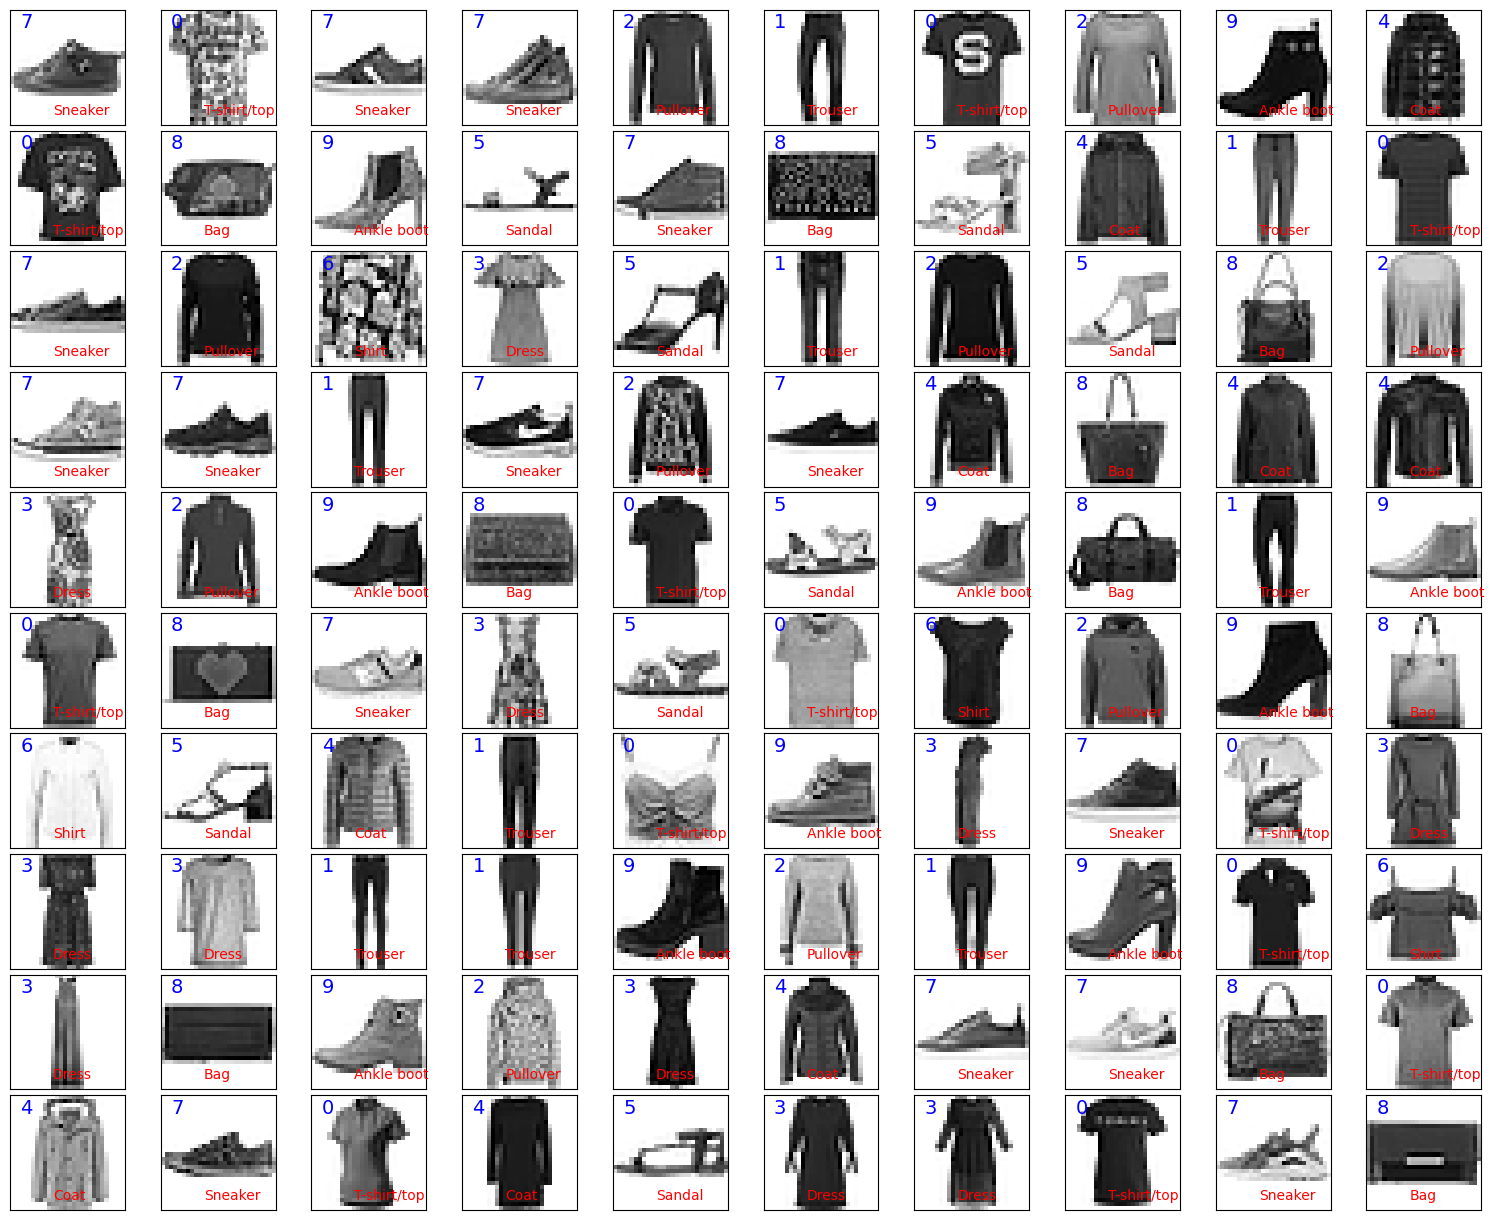

In [14]:
# sample data plot

plot_df = train_df.sample(n=100) # take 100 sample from the training set
fig = plt.figure(figsize=(15, 12)) # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust

i = 0
for _, row in plot_df.iterrows(): # iterate through all rows of the dataframe
    i = i + 1
    image = row.values[1:].reshape(28, 28) # reshape row to a 28 x 28 matrix
    ax = fig.add_subplot(10, 10, (i), xticks=[], yticks=[]) 
    ax.imshow(image, cmap=plt.cm.binary, interpolation='nearest')
    ax.text(2, 4, str(row.iloc[0]), color='b', fontsize=14)
    ax.text(10, 25, class_names[row.iloc[0]], color='r', fontsize=10)

plt.show()

In [97]:
initializer = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)
regularizer = tf.keras.regularizers.L2(0.05)
dor1,dor2 = 0.2,0.1

model = tf.keras.Sequential([
    tf.keras.Input(shape = (784,)),
    tf.keras.layers.Dense(146,
                          kernel_initializer=initializer,
                          kernel_regularizer=regularizer,
                         ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(dor1),
    # tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(36,
                          # activation='relu',
                          kernel_initializer = initializer, 
                          kernel_regularizer=regularizer),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(dor2),
    # tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Dense(10)
])

In [98]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA)
model.compile(optimizer = optimizer,
             loss = loss_fn,
             
             metrics = ['accuracy'])

In [99]:
#call backs

tb_callback = tf.keras .callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss',
                                              patience=PATIENCE,
                                              verbose = 1,
                                              restore_best_weights=True,
)

chkpt_filepath =' modelDir/subDir/all_in.keras'
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(    
    chkpt_filepath,
    monitor= 'val_loss',
    verbose = 1,
    save_best_only = True,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
   monitor='val_loss',
    factor= LR_FACTOR,
    patience = LR_PATIENCE,
    verbose = 1,
    mode = 'auto',
    min_lr=MIN_LR
)



In [100]:
history = model.fit(train_ds,
                    validation_data=test_ds,
                    callbacks=[tb_callback,es_callback,chkpt_callback,lr_callback],
                    epochs=EPOCHS)

Epoch 1/30
937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7390 - loss: 4.0107
Epoch 1: val_loss improved from None to 0.87864, saving model to  modelDir/subDir/all_in.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7649 - loss: 1.8118 - val_accuracy: 0.7874 - val_loss: 0.8786 - learning_rate: 0.0010
Epoch 2/30
929/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7737 - loss: 0.8909
Epoch 2: val_loss improved from 0.87864 to 0.81743, saving model to  modelDir/subDir/all_in.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7742 - loss: 0.8770 - val_accuracy: 0.7974 - val_loss: 0.8174 - learning_rate: 0.0010
Epoch 3/30
929/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7759 - loss: 0.8520
Epoch 3: val_loss improved from 0.81743 to 0.77234, saving model to  modelDir/subDir/all_in.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7798 - loss: 0.8398 - val_accuracy: 0.8041 - val_loss: 0.7723 - learning_rate: 0.0010
Epoch 4/30
935/938 ━━━━━━━━━

In [101]:
model.evaluate(train_ds,verbose=2)

938/938 - 2s - 2ms/step - accuracy: 0.8269 - loss: 0.6561


[0.6560717225074768, 0.8269166946411133]

In [102]:
y_true,y_pred = [],[]
for feat,lbls in train_ds:
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis = 1))
print(f'Accuracy : {accuracy_score(y_true,y_pred)}')
print(f'Accuracy : {classification_report(y_true,y_pred)}')

Accuracy : 0.8269166666666666
Accuracy :               precision    recall  f1-score   support

           0       0.75      0.84      0.80      6000
           1       0.95      0.96      0.95      6000
           2       0.81      0.64      0.72      6000
           3       0.81      0.87      0.84      6000
           4       0.73      0.78      0.75      6000
           5       0.90      0.91      0.90      6000
           6       0.64      0.54      0.59      6000
           7       0.92      0.83      0.87      6000
           8       0.90      0.93      0.91      6000
           9       0.85      0.96      0.90      6000

    accuracy                           0.83     60000
   macro avg       0.83      0.83      0.82     60000
weighted avg       0.83      0.83      0.82     60000



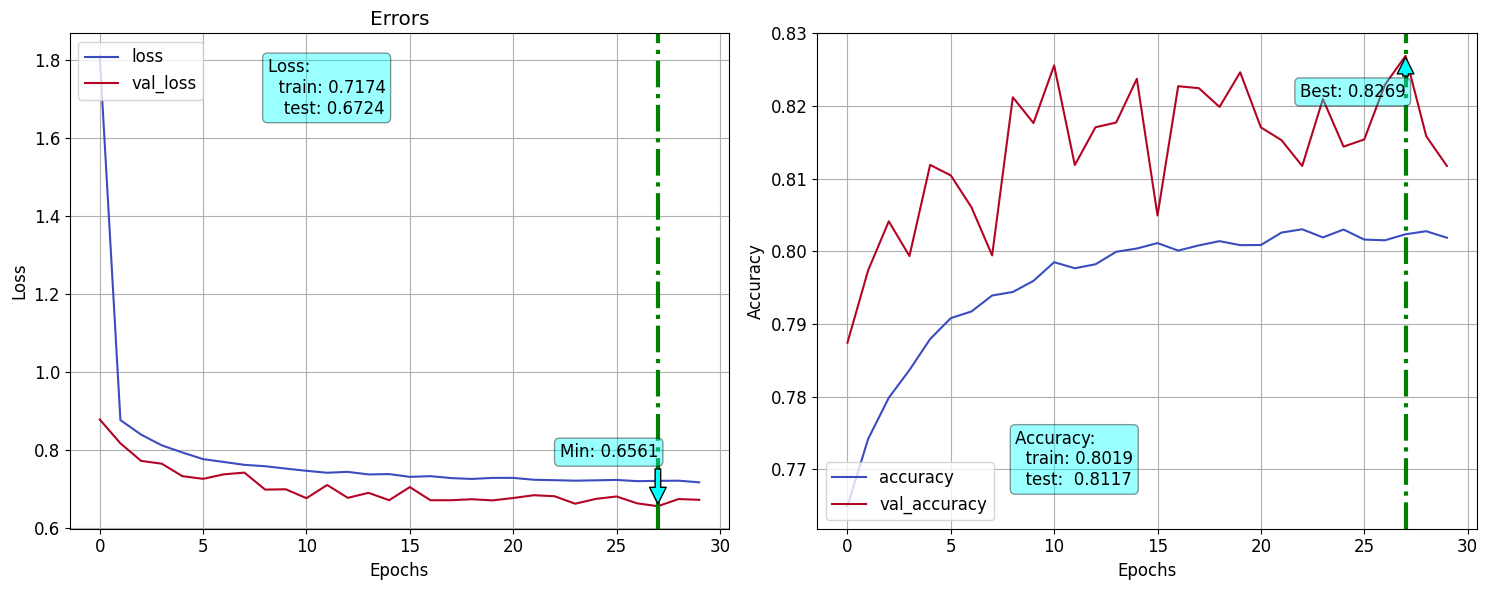

In [103]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

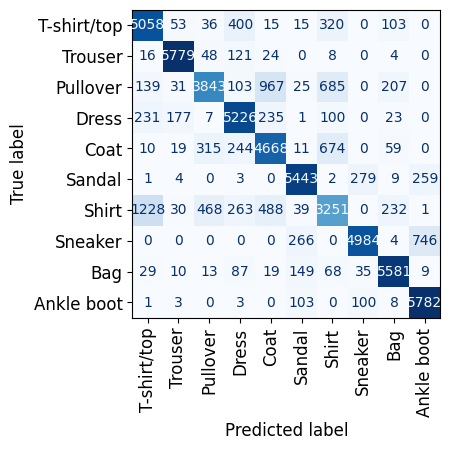

In [104]:
fn_plot_confusion_matrix(y_true,y_pred,class_names)